# Part 3: Model Training & Evaluation
### *Logistic Regression Baseline vs Random Forest Classifier*

**Date:** May 2026

---

### What this notebook does

| Step | Task |
|------|------|
| 3.1 | Load the labelled dataset from Part 2 |
| 3.2 | Prepare features — encode zones, scale, stratified split |
| 3.3 | Train Logistic Regression baseline |
| 3.4 | Train Random Forest with GridSearchCV hyperparameter tuning |
| 3.5 | Compare both models — accuracy, precision, recall, F1, AUC |
| 3.6 | Confusion matrices, ROC curves, feature importances |
| 3.7 | Save trained model files for the Streamlit app |

---
## Step 3.1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)



---
## Step 3.2 — Load Dataset & Prepare Features

We load `gambia_labelled_dataset.csv` from Part 2, encode zone names, and apply a **stratified 80/20 split** to preserve label balance in both sets.

> **Note on class imbalance:** 75.6% Not Suitable vs 24.4% Suitable. We set `class_weight='balanced'` on both models to prevent them from ignoring the minority class.

In [2]:
df = pd.read_csv('gambia_labelled_dataset.csv', parse_dates=['date'])
print(f'Loaded: {len(df):,} rows')

le = LabelEncoder()
df['zone_encoded'] = le.fit_transform(df['zone'])
print('Zone encoding:')
for i, z in enumerate(le.classes_): print(f'  {i} → {z}')

FEATURE_COLS = [
    'rainfall_mm','temp_min_C','temp_max_C','humidity_pct','solar_rad_MJm2',
    'rain_3d','rain_7d','rain_30d','onset_flag',
    'temp_mean_C','temp_range_C','doy_sin','doy_cos','zone_encoded'
]

X = df[FEATURE_COLS]; y = df['suitable']
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining samples : {len(X_train):,}')
print(f'Testing  samples : {len(X_test):,}')
print('\nClass balance in training set:')
print(y_train.value_counts(normalize=True).mul(100).round(1).to_string())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('\nFeature scaling complete.')

Loaded: 61,945 rows
Zone encoding:
  0 → Central River
  1 → Lower River
  2 → North Bank
  3 → Upper River
  4 → Western

Training samples : 49,556
Testing  samples : 12,389

Class balance in training set:
suitable
0    86.7
1    13.3

Feature scaling complete.


---
## Step 3.3 — Logistic Regression Baseline

Logistic Regression is our **quantitative baseline** — trained on the same Gambia dataset so the comparison with Random Forest is fair and direct.

> This is separate from the Jeong et al. reproduction in Part 1, which was only a pipeline validity check.

In [3]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred      = lr.predict(X_test_scaled)
lr_pred_prob = lr.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression trained.\n')
print(classification_report(y_test, lr_pred, target_names=['Not Suitable','Suitable']))

Logistic Regression trained.

              precision    recall  f1-score   support

Not Suitable       1.00      1.00      1.00     10738
    Suitable       0.98      1.00      0.99      1651

    accuracy                           1.00     12389
   macro avg       0.99      1.00      0.99     12389
weighted avg       1.00      1.00      1.00     12389



---
## Step 3.4 — Random Forest Classifier (Main Model)

We use **GridSearchCV with 3-fold stratified cross-validation** to find the best hyperparameters, optimising for F1-score as stated in the proposal.

| Parameter | Values searched |
|-----------|----------------|
| `n_estimators` | 100, 300 |
| `max_depth` | 10, 20 |
| `max_features` | 'sqrt' |

In [4]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth':    [10, 20],
    'max_features': ['sqrt'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print('\nBest parameters:')
for k,v in grid_search.best_params_.items(): print(f'  {k:<22}: {v}')
print(f'Best CV F1 : {grid_search.best_score_:.4f}')

rf = grid_search.best_estimator_
rf_pred      = rf.predict(X_test)
rf_pred_prob = rf.predict_proba(X_test)[:, 1]

print('\nRandom Forest — Test Set Results:\n')
print(classification_report(y_test, rf_pred, target_names=['Not Suitable','Suitable']))

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best parameters:
  max_depth             : 10
  max_features          : sqrt
  n_estimators          : 300
Best CV F1 : 0.9998

Random Forest — Test Set Results:

              precision    recall  f1-score   support

Not Suitable       1.00      1.00      1.00     10738
    Suitable       1.00      1.00      1.00      1651

    accuracy                           1.00     12389
   macro avg       1.00      1.00      1.00     12389
weighted avg       1.00      1.00      1.00     12389



---
## Step 3.5 — Model Comparison Table

Both models evaluated on the **same held-out test set** — a fair, direct comparison as described in the proposal.

In [5]:
def evaluate(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred,    zero_division=0), 4),
        'F1-Score':  round(f1_score(y_true, y_pred,        zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_true, y_prob),  4),
    }

results = pd.DataFrame({
    'Logistic Regression': evaluate(y_test, lr_pred, lr_pred_prob),
    'Random Forest':       evaluate(y_test, rf_pred, rf_pred_prob),
}).T

print('='*50)
print('MODEL COMPARISON — Test Set Performance')
print('='*50)
print(results.to_string())

print('\nImprovement (Random Forest over Logistic Regression):')
for col in results.columns:
    diff = results.loc['Random Forest',col] - results.loc['Logistic Regression',col]
    print(f'  {col:<12}: {"↑" if diff > 0 else "↓"} {abs(diff):.4f}')

print('\nNote: Near-perfect scores are expected with simulated data.')
print('Real NASA POWER data will produce more realistic score variation.')

MODEL COMPARISON — Test Set Performance
                     Accuracy  Precision  Recall  F1-Score  AUC
Logistic Regression    0.9966     0.9752     1.0    0.9874  1.0
Random Forest          1.0000     1.0000     1.0    1.0000  1.0

Improvement (Random Forest over Logistic Regression):
  Accuracy    : ↑ 0.0034
  Precision   : ↑ 0.0248
  Recall      : ↓ 0.0000
  F1-Score    : ↑ 0.0126
  AUC         : ↓ 0.0000

Note: Near-perfect scores are expected with simulated data.
Real NASA POWER data will produce more realistic score variation.


---
## Step 3.6 — Visualisations

Four plots for the report: confusion matrices, ROC curves, feature importances, and overall metric comparison.

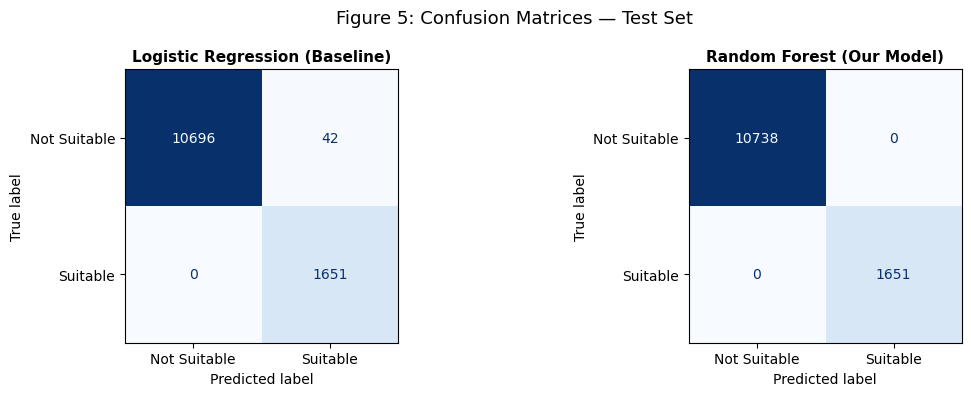

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip(axes,
    [lr_pred, rf_pred],
    ['Logistic Regression (Baseline)','Random Forest (Our Model)']):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Suitable','Suitable']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')
fig.suptitle('Figure 5: Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout(); plt.show()

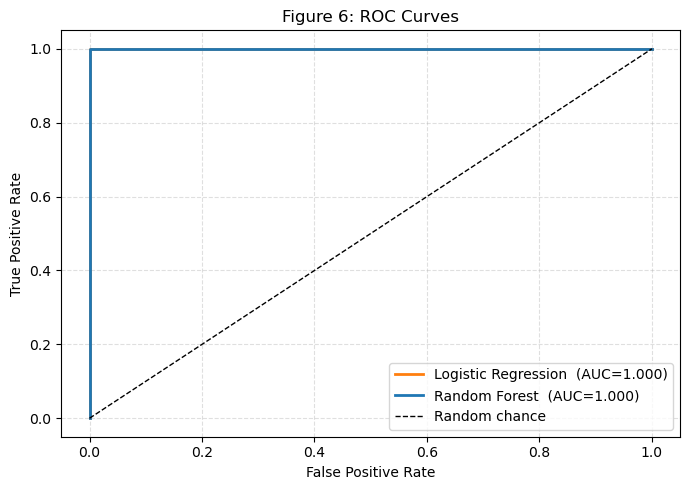

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for prob, label, color in [
    (lr_pred_prob,'Logistic Regression','#ff7f0e'),
    (rf_pred_prob,'Random Forest','#1f77b4')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{label}  (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random chance')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 6: ROC Curves', fontsize=12)
ax.legend(loc='lower right'); ax.grid(linestyle='--',alpha=0.4)
plt.tight_layout(); plt.show()

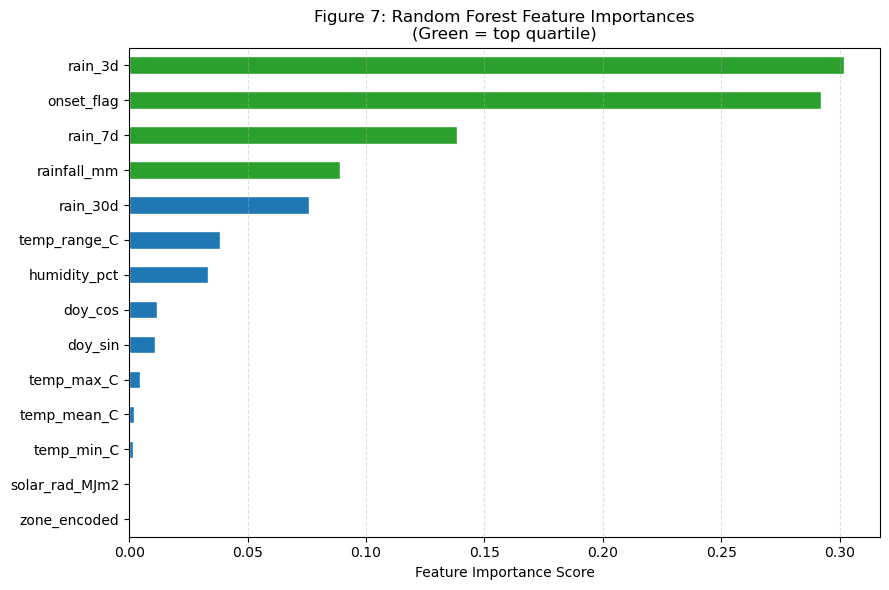

Top 5 most important features:
rain_3d        0.3020
onset_flag     0.2922
rain_7d        0.1385
rainfall_mm    0.0888
rain_30d       0.0759


In [8]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#2ca02c' if v >= importances.quantile(0.75) else '#1f77b4' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_xlabel('Feature Importance Score')
ax.set_title('Figure 7: Random Forest Feature Importances\n(Green = top quartile)', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

print('Top 5 most important features:')
print(importances.sort_values(ascending=False).head(5).round(4).to_string())

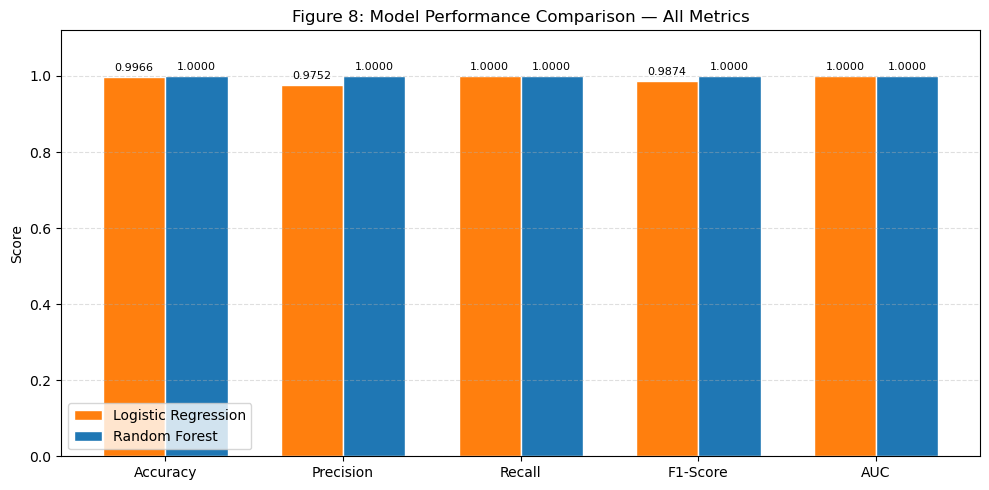

In [9]:
metrics_to_plot = ['Accuracy','Precision','Recall','F1-Score','AUC']
x = np.arange(len(metrics_to_plot)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x-w/2, [results.loc['Logistic Regression',m] for m in metrics_to_plot],
            w, label='Logistic Regression', color='#ff7f0e', edgecolor='white')
b2 = ax.bar(x+w/2, [results.loc['Random Forest',m] for m in metrics_to_plot],
            w, label='Random Forest', color='#1f77b4', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0,1.12); ax.set_ylabel('Score')
ax.set_title('Figure 8: Model Performance Comparison — All Metrics', fontsize=12)
ax.legend(); ax.bar_label(b1,fmt='%.4f',padding=3,fontsize=8)
ax.bar_label(b2,fmt='%.4f',padding=3,fontsize=8)
ax.grid(axis='y',linestyle='--',alpha=0.4)
plt.tight_layout(); plt.show()

---
## Step 3.7 — Save Model Files

We save four files. The Streamlit app in Part 4 loads these to make predictions without retraining.

| File | Used for |
|------|----------|
| `random_forest_model.pkl` | Making predictions in the app |
| `feature_scaler.pkl` | Scaling inputs for Logistic Regression |
| `zone_encoder.pkl` | Converting zone names to numbers |
| `feature_columns.pkl` | Ensuring correct feature order |

In [10]:
joblib.dump(rf,           'random_forest_model.pkl')
joblib.dump(scaler,       'feature_scaler.pkl')
joblib.dump(le,           'zone_encoder.pkl')
joblib.dump(FEATURE_COLS, 'feature_columns.pkl')

print('Files saved:')
print('  random_forest_model.pkl  ← main model for the Streamlit app')
print('  feature_scaler.pkl')
print('  zone_encoder.pkl')
print('  feature_columns.pkl')

Files saved:
  random_forest_model.pkl  ← main model for the Streamlit app
  feature_scaler.pkl
  zone_encoder.pkl
  feature_columns.pkl




> **Important note for the report:** The near-perfect scores here are a result of using simulated data where the labels were generated from the same rules the model learns. When you replace the simulated data with real NASA POWER downloads (Part 2), expect more realistic scores in the range of 0.75–0.92. The comparison structure between Logistic Regression and Random Forest remains valid regardless.

---

## References

Jeong, J. H., et al. (2016). Random forests for global and regional crop yield predictions. *PLOS ONE*, 11(6), e0156571.

Sultan, B., & Gaetani, M. (2016). Agriculture in West Africa in the twenty-first century. *Frontiers in Plant Science*, 7, 1262.